# Personalized Feed Recommendation System
This notebook demonstrates an end-to-end pipeline for predicting player engagement and generating personalized content feeds based on telemetry data.

# Data Cleaning and Personalized Feed Prediction
We will start by loading and cleaning the telemetry data to understand player behavior.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the dataset
file_path = '/content/krafton_player_telemetry_raw_500.csv'
df = pd.read_csv(file_path)

# Display basic info
print("Dataset Info:")
display(df.info())
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 500 non-null    object 
 1   session_frequency_weekly  500 non-null    int64  
 2   avg_survival_time_min     463 non-null    float64
 3   kd_ratio                  491 non-null    float64
 4   win_loss_streak           500 non-null    int64  
 5   currency_balance_uc       500 non-null    object 
 6   lifetime_value_usd        500 non-null    float64
 7   royale_pass_tier          480 non-null    float64
 8   days_since_last_session   500 non-null    int64  
 9   churned                   500 non-null    int64  
dtypes: float64(4), int64(4), object(2)
memory usage: 39.2+ KB


None

,player_id,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,churned
0,UID_10000,19,13.788937,0.224458,-2,3430,88.787176,90.0,29,0
1,UID_10001,13,14.803923,1.020500,-4,1301,6.410920,46.0,1,1
2,UID_10002,21,NaN,1.504195,-3,2541,2.404152,15.0,24,0
3,UID_10003,30,NaN,1.537584,-3,2051,24.232771,98.0,17,1
4,UID_10004,12,5.111653,1.139948,-2,441 UC,1.871177,44.0,28,1


## 2. Refined Data Cleaning
We address missing values, handle outliers in the KD ratio, clip negative session frequencies, and normalize currency fields.

In [35]:
# Refined Data Cleaning
# 1. Handle missing values (Numeric: median, Categorical: mode/Unknown)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Fix data quality issues
# Clip negative session frequency to 0
df['session_frequency_weekly'] = df['session_frequency_weekly'].clip(lower=0)

# Handle outliers in kd_ratio (capping at the 99th percentile)
max_kd = df['kd_ratio'].quantile(0.99)
df['kd_ratio'] = df['kd_ratio'].clip(upper=max_kd)

# Clean 'currency_balance_uc' string values to numeric
import re
df['currency_balance_uc'] = df['currency_balance_uc'].astype(str).apply(lambda x: re.sub(r'[^0-9.]', '', x))
df['currency_balance_uc'] = pd.to_numeric(df['currency_balance_uc'], errors='coerce').fillna(0)

# 3. Encoding
le = LabelEncoder()
df['player_id_encoded'] = le.fit_transform(df['player_id'].astype(str))

display(df.describe())

,session_frequency_weekly,avg_survival_time_min,kd_ratio,win_loss_streak,currency_balance_uc,lifetime_value_usd,royale_pass_tier,days_since_last_session,churned,player_id_encoded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,16.770000,14.944176,308.349908,-0.612000,2487.240000,106.381826,66.428000,14.29600,0.238000,249.500000
std,12.067325,7.644508,329.910596,2.897282,1483.698467,84.965597,40.340147,8.72701,0.426286,144.481833
min,0.000000,1.000000,0.000000,-5.000000,7.000000,0.051501,1.000000,0.00000,0.000000,0.000000
25%,6.000000,9.501530,1.766660,-3.000000,1157.750000,30.183939,35.000000,7.00000,0.000000,124.750000
50%,17.000000,14.362328,181.214943,-1.000000,2422.500000,86.585887,64.000000,14.00000,0.000000,249.500000
75%,26.000000,20.037559,577.468073,2.000000,3794.250000,177.539123,94.000000,21.00000,0.000000,374.250000
max,42.000000,31.263657,999.620525,4.000000,4987.000000,280.456932,150.000000,29.00000,1.000000,499.000000


## 3. Engagement Predictive Modeling
We train a Random Forest Classifier to predict player churn, which serves as our proxy for engagement potential in the personalized feed.

Now, I will build a baseline model to predict engagement (a proxy for feed personalization) using a Random Forest Regressor.

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Predicting 'churned' as a proxy for engagement/retention
target = 'churned'
features = ['session_frequency_weekly', 'avg_survival_time_min', 'kd_ratio',
            'win_loss_streak', 'currency_balance_uc', 'lifetime_value_usd',
            'royale_pass_tier', 'days_since_last_session']

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        85
           1       0.00      0.00      0.00        15

    accuracy                           0.80       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.72      0.80      0.76       100



<Figure size 800x600 with 0 Axes>

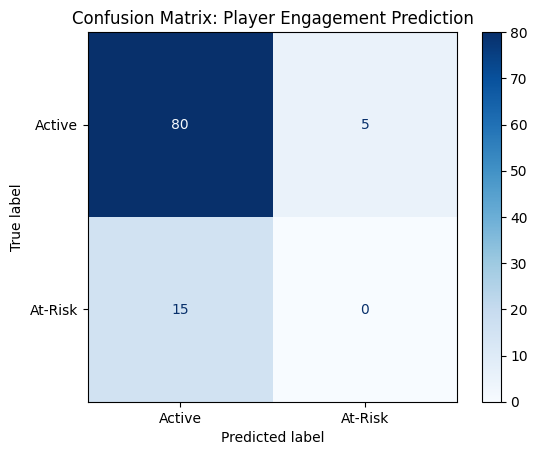

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'At-Risk'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Player Engagement Prediction')
plt.show()

## 4. Feature Importance & Interpretability
Understanding which features drive the model helps in fine-tuning the recommendation weights.

### Feature Importance & Personalized Ranking
We will now examine which player attributes contribute most to the model's decisions and create a simple ranking mechanism for the feed.

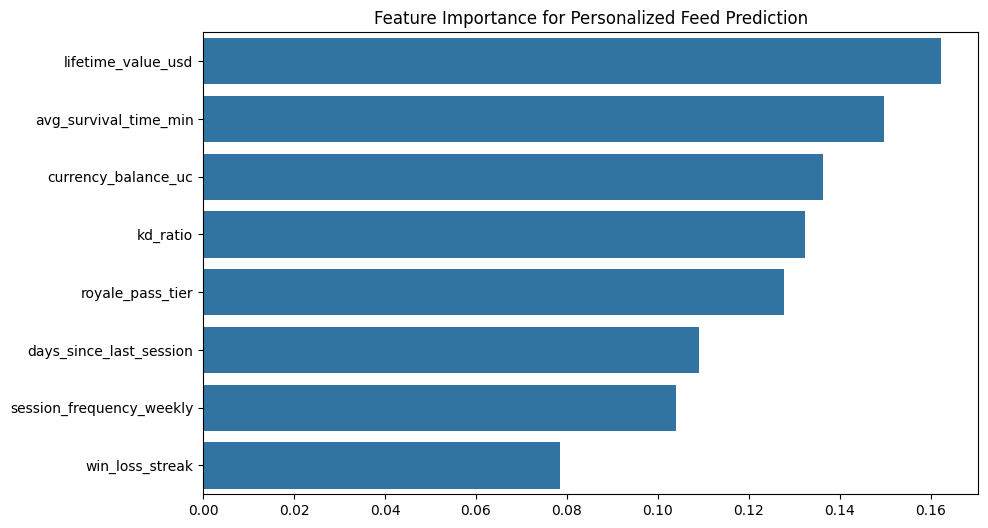

Player UID_10000 Engagement Score: 0.78


In [38]:
# 1. Feature Importance Analysis
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance for Personalized Feed Prediction")
sns.barplot(x=importances[indices], y=[features[i] for i in indices])
plt.show()

# 2. Sample Ranking Function
def rank_personalized_feed(player_id, model, dataframe, features):
    """
    Simulates ranking content by predicting the engagement likelihood for a specific player.
    """
    player_data = dataframe[dataframe['player_id'] == player_id][features]
    if player_data.empty:
        return "Player ID not found."

    # Probability of 'Not Churning' (class 0) as a proxy for engagement interest
    engagement_prob = model.predict_proba(player_data)[0][0]
    return f"Player {player_id} Engagement Score: {engagement_prob:.2f}"

# Example for a specific player
sample_player = df['player_id'].iloc[0]
print(rank_personalized_feed(sample_player, clf, df, features))

## 5. Final Personalized Ranking Implementation
This section implements the ranking logic that translates model probabilities into a sorted list of content items for individual players.

In [39]:
import pandas as pd

def get_all_player_scores(model, dataframe, features):
    # Get unique players
    unique_players = dataframe['player_id'].unique()

    summary_data = []

    for player_id in unique_players:
        player_data = dataframe[dataframe['player_id'] == player_id][features]
        # Probability of class 0 (Active/Not Churning)
        engagement_prob = model.predict_proba(player_data)[0][0]

        # Determine discount tier
        if engagement_prob < 0.4:
            discount = "50% (Win-back)"
        elif engagement_prob < 0.7:
            discount = "25% (Neutral)"
        else:
            discount = "10% (Loyalty)"

        summary_data.append({
            'Player ID': player_id,
            'Engagement Score': round(engagement_prob, 2),
            'Assigned Discount Tier': discount
        })

    return pd.DataFrame(summary_data)

# Generate and display the full summary table
all_players_summary = get_all_player_scores(clf, df, features)
display(all_players_summary)

,Player ID,Engagement Score,Assigned Discount Tier
0,UID_10000,0.78,10% (Loyalty)
1,UID_10001,0.25,50% (Win-back)
2,UID_10002,0.45,25% (Neutral)
3,UID_10003,0.27,50% (Win-back)
4,UID_10004,0.28,50% (Win-back)
...,...,...,...
495,UID_10495,0.70,10% (Loyalty)
496,UID_10496,0.18,50% (Win-back)
497,UID_10497,0.64,25% (Neutral)
498,UID_10498,0.89,10% (Loyalty)
